In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [4]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [5]:
file_path = "CFPB Complaints Data - Jan25 to Mar26.xlsx"

df = pd.read_excel(file_path)

df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Complaint ID
0,2025-01-02T19:16:49.000Z,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,NaN,CAPITAL ONE FINANCIAL CORPORATION,LA,70301,Web,Closed with explanation,Yes,11355363
1,2025-01-01T13:44:37.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Company has responded to the consumer and the ...,BARCLAYS BANK DELAWARE,FL,33626,Web,Closed with explanation,Yes,11345211
2,2025-01-01T05:02:06.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,CAPITAL ONE FINANCIAL CORPORATION,NJ,7501,Web,Closed with explanation,Yes,11346155
3,2025-01-01T00:05:25.000Z,Credit card,General-purpose credit card or charge card,Getting a credit card,Delay in processing application,NaN,JPMORGAN CHASE & CO.,WA,981XX,Web,Closed with monetary relief,Yes,11335575
4,2025-01-01T02:37:03.000Z,Credit reporting or other personal consumer re...,Credit reporting,Credit monitoring or identity theft protection...,Problem canceling credit monitoring or identif...,NaN,CAPITAL ONE FINANCIAL CORPORATION,TX,75078,Web,Closed with explanation,Yes,11345786


In [6]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Shape : (196835, 13)

Columns
Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company', 'State', 'ZIP code',
       'Submitted via', 'Company response to consumer', 'Timely response?',
       'Complaint ID'],
      dtype='str')

Data Types
Date received                      str
Product                            str
Sub-product                        str
Issue                              str
Sub-issue                          str
Company public response            str
Company                            str
State                              str
ZIP code                        object
Submitted via                      str
Company response to consumer       str
Timely response?                   str
Complaint ID                     int64
dtype: object

Missing Values
Date received                       0
Product                             0
Sub-product                         0
Issue                               0
Sub-issue   

In [8]:
print(df.columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company', 'State', 'ZIP code', 'Submitted via', 'Company response to consumer', 'Timely response?', 'Complaint ID']


In [9]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Convert Date received to datetime
df["Date received"] = pd.to_datetime(df["Date received"])

# Create Month and Year columns
df["Month"] = df["Date received"].dt.month_name()
df["Year"] = df["Date received"].dt.year
df["Month-Year"] = df["Date received"].dt.to_period("M")

print("Data cleaned successfully!")

Data cleaned successfully!


C:\Users\adity\AppData\Local\Temp\ipykernel_17864\1565392646.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["Month-Year"] = df["Date received"].dt.to_period("M")


In [10]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nUnique Companies :", df["Company"].nunique())
print("Unique Products :", df["Product"].nunique())
print("Unique Issues :", df["Issue"].nunique())

print("\nDate Range")
print(df["Date received"].min())
print(df["Date received"].max())

DATASET OVERVIEW
Rows : 196835
Columns : 16

Unique Companies : 9
Unique Products : 11
Unique Issues : 83

Date Range
2025-01-01 00:03:37+00:00
2026-03-31 23:59:35+00:00


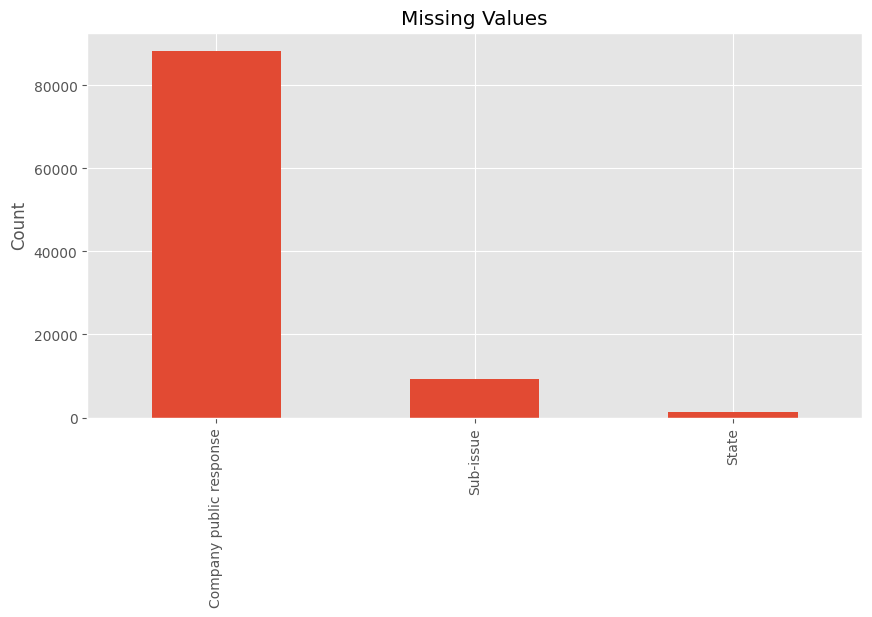

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing>0]

plt.figure(figsize=(10,5))

missing.plot(kind='bar')

plt.title("Missing Values")

plt.ylabel("Count")

plt.show()

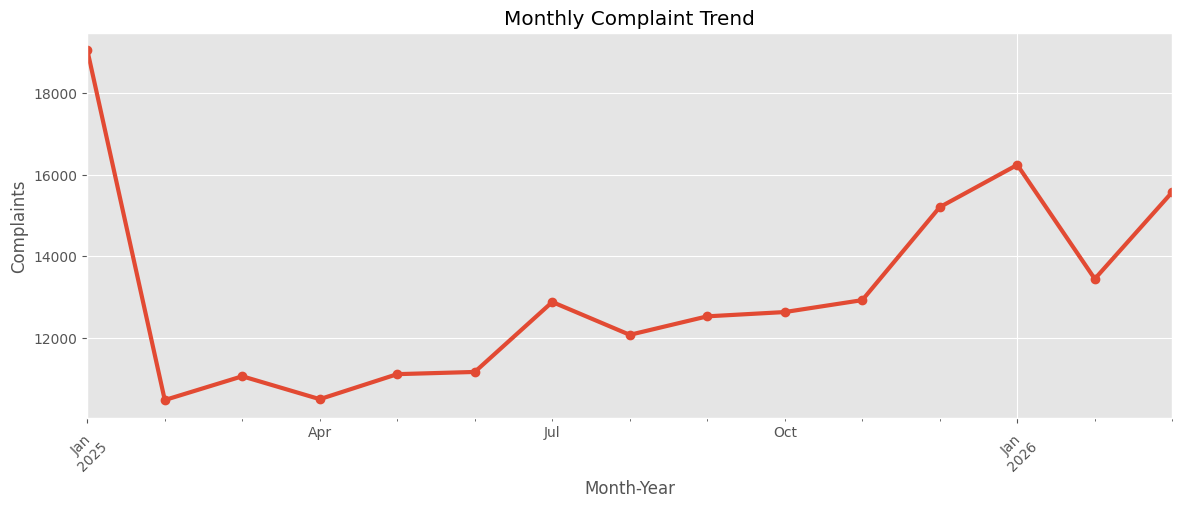

In [12]:
monthly = df.groupby("Month-Year").size()

plt.figure(figsize=(14,5))

monthly.plot(marker='o', linewidth=3)

plt.title("Monthly Complaint Trend")

plt.ylabel("Complaints")

plt.xticks(rotation=45)

plt.show()

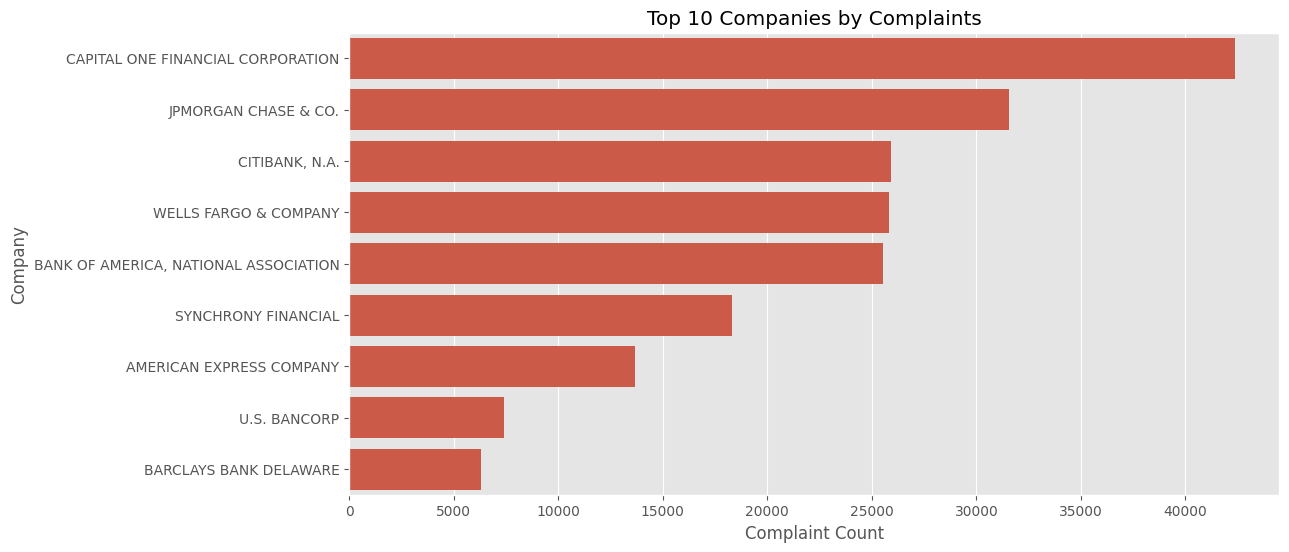

In [13]:
top_company = df["Company"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_company.values,
    y=top_company.index
)

plt.title("Top 10 Companies by Complaints")

plt.xlabel("Complaint Count")

plt.show()

In [14]:
amex = df[df["Company"]=="AMERICAN EXPRESS COMPANY"]

print("Total AmEx Complaints :", len(amex))

Total AmEx Complaints : 13665


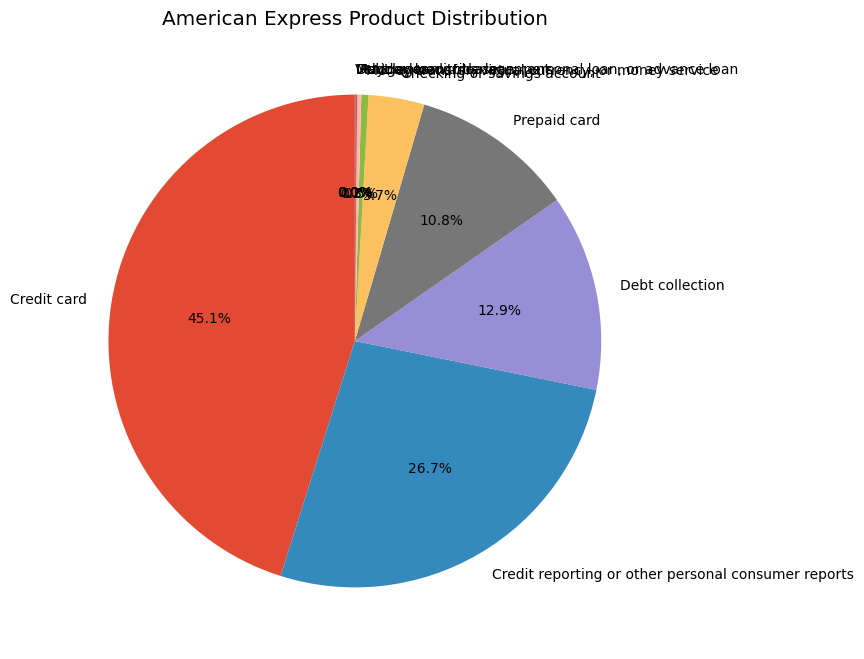

In [15]:
product = amex["Product"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    product.values,
    labels=product.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("American Express Product Distribution")

plt.show()

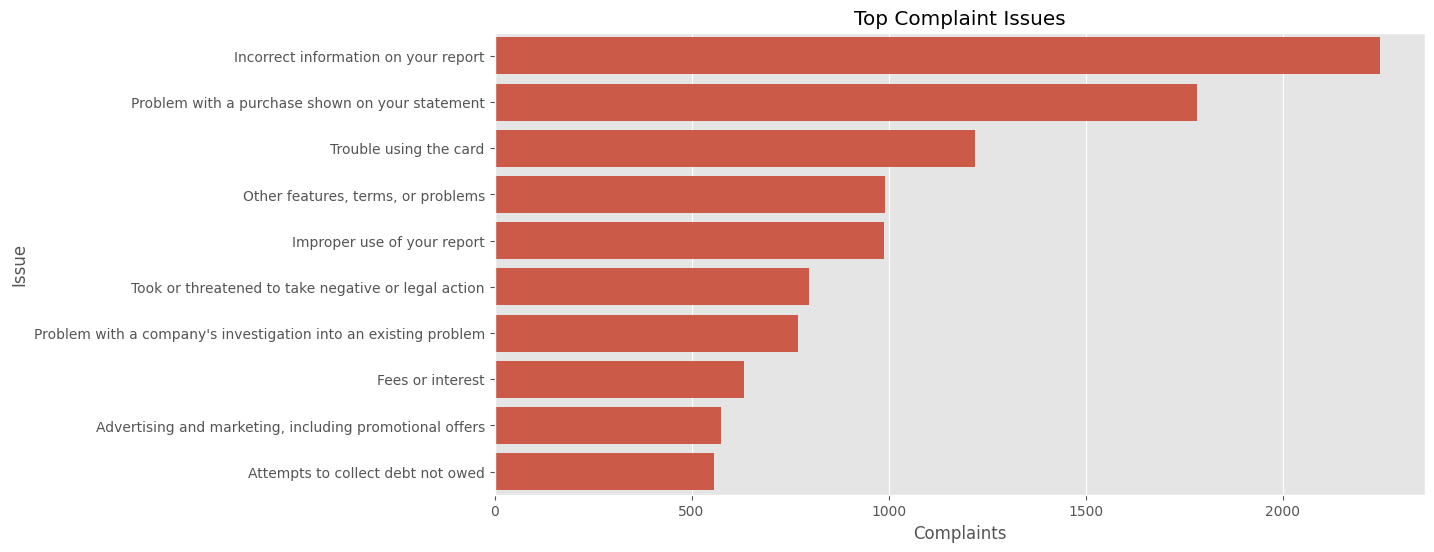

In [16]:
issue = amex["Issue"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=issue.values,
    y=issue.index
)

plt.title("Top Complaint Issues")

plt.xlabel("Complaints")

plt.show()

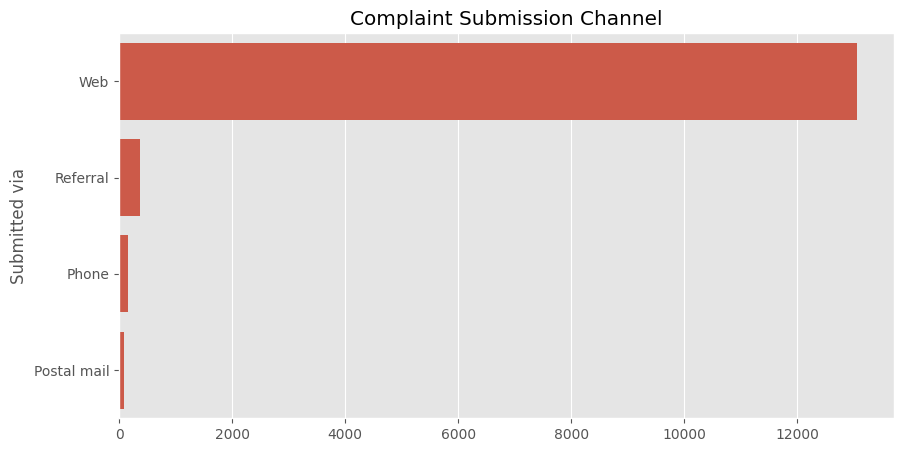

In [17]:
channel = amex["Submitted via"].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=channel.values,
    y=channel.index
)

plt.title("Complaint Submission Channel")

plt.show()

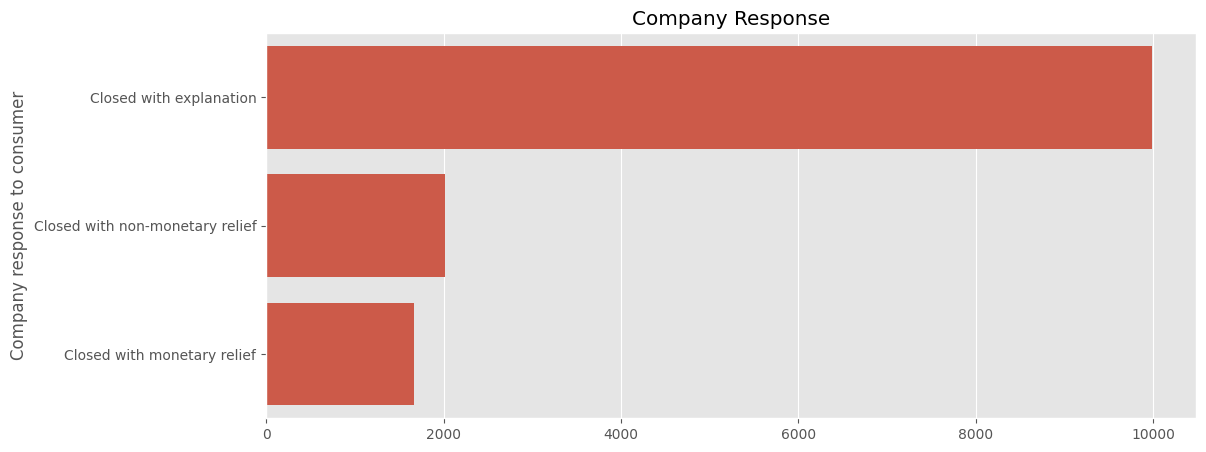

In [18]:
response = amex["Company response to consumer"].value_counts()

plt.figure(figsize=(12,5))

sns.barplot(
    x=response.values,
    y=response.index
)

plt.title("Company Response")

plt.show()

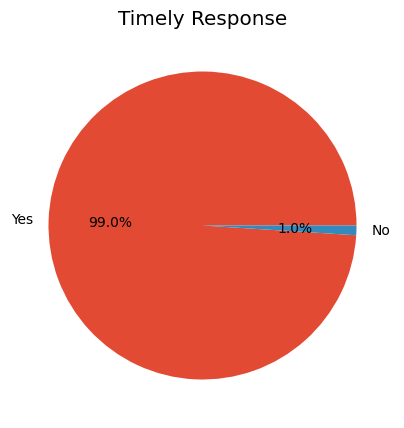

In [19]:
timely = amex["Timely response?"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    timely.values,
    labels=timely.index,
    autopct="%1.1f%%"
)

plt.title("Timely Response")

plt.show()

In [20]:
print(df["Company"].unique())
print(df["Company"].nunique())

<StringArray>
[    'CAPITAL ONE FINANCIAL CORPORATION',
                'BARCLAYS BANK DELAWARE',
                  'JPMORGAN CHASE & CO.',
                        'CITIBANK, N.A.',
              'AMERICAN EXPRESS COMPANY',
                          'U.S. BANCORP',
                 'WELLS FARGO & COMPANY',
                   'SYNCHRONY FINANCIAL',
 'BANK OF AMERICA, NATIONAL ASSOCIATION']
Length: 9, dtype: str
9


In [21]:
df.groupby("Month-Year").size()

Month-Year
2025-01    19049
2025-02    10476
2025-03    11058
2025-04    10497
2025-05    11110
2025-06    11164
2025-07    12877
2025-08    12073
2025-09    12526
2025-10    12631
2025-11    12923
2025-12    15201
2026-01    16236
2026-02    13443
2026-03    15571
Freq: M, dtype: int64